In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_RAW = Path(r"C:\Users\syeds\OneDrive\Desktop\nboracle\nb_oracle\data\raw\store-sales-time-series-forecasting")

train = pd.read_csv(DATA_RAW / "train.csv", parse_dates=["date"])

# Focus on Store 44 again
store44 = train[train.store_nbr == 44].copy()
print(f"Loaded {len(store44):,} rows for Store 44")

Loaded 55,572 rows for Store 44


In [3]:
# THE BASELINE MODEL
# For each day, predict sales = average of the same day-of-week 
# from the past 4 weeks.
#
# Example: To predict Saturday's beverage sales,
# look at the last 4 Saturdays and average them.

def baseline_predict(df, category):
    """
    For a given product category, create baseline predictions.
    Returns a dataframe with actual sales and predicted sales.
    """
    # Get just this category, sorted by date
    cat_data = (df[df.family == category]
                .sort_values("date")
                .set_index("date")[["sales"]]
                .copy())
    
    # Add day-of-week (0=Monday, 6=Sunday)
    cat_data["dow"] = cat_data.index.dayofweek
    
    # For each row, calculate the average of the same day-of-week
    # from the previous 4 weeks
    predictions = []
    
    for i in range(len(cat_data)):
        current_date = cat_data.index[i]
        current_dow = cat_data["dow"].iloc[i]
        
        # Look at all previous rows with the same day of week
        past = cat_data.iloc[:i]  # Everything BEFORE this date
        same_dow = past[past["dow"] == current_dow]["sales"]
        
        # Average of last 4 same-day-of-week values
        last_4 = same_dow.tail(4)
        
        if len(last_4) > 0:
            pred = last_4.mean()
        else:
            pred = 0  # No history yet, predict 0
        
        predictions.append(pred)
    
    cat_data["predicted"] = predictions
    return cat_data

# Run it for BEVERAGES (this might take 30-60 seconds)
print("Building baseline predictions for BEVERAGES...")
bev_baseline = baseline_predict(store44, "BEVERAGES")
print("Done!")
print(f"\nFirst few predictions vs actuals:")
print(bev_baseline[["sales", "predicted"]].tail(10).round(1).to_string())

Building baseline predictions for BEVERAGES...
Done!

First few predictions vs actuals:
              sales  predicted
date                          
2017-08-06  12913.0    16180.8
2017-08-07   8254.0     9933.8
2017-08-08   6967.0     8504.5
2017-08-09   7679.0     8877.2
2017-08-10   7595.0     8300.0
2017-08-11   9517.0     9346.5
2017-08-12   9624.0    15452.8
2017-08-13  10491.0    15491.5
2017-08-14   7322.0     9807.2
2017-08-15   7351.0     8250.8


In [4]:
# HOW DO WE MEASURE PREDICTION QUALITY?
# 
# We use WMAPE (Weighted Mean Absolute Percentage Error)
# In plain English: "on average, how far off are our predictions?"
# Lower = better. 0.20 means "off by about 20%"

def compute_wmape(actual, predicted):
    """
    WMAPE: total error divided by total actual sales.
    Handles zeros better than regular MAPE.
    """
    total_actual = np.sum(np.abs(actual))
    if total_actual == 0:
        return 0.0
    total_error = np.sum(np.abs(actual - predicted))
    return total_error / total_actual

# Only measure on data where we had enough history (skip first 28 days)
eval_data = bev_baseline.iloc[28:].copy()

# Split: use last 30 days as our "test" set
# (pretend we haven't seen these yet)
test_data = eval_data.last("30D") if hasattr(eval_data, 'last') else eval_data[eval_data.index >= eval_data.index.max() - pd.Timedelta(days=30)]
train_data = eval_data[eval_data.index < test_data.index.min()]

wmape = compute_wmape(test_data["sales"].values, test_data["predicted"].values)
print(f"Baseline WMAPE on last 30 days: {wmape:.4f}")
print(f"In plain English: predictions are off by about {wmape*100:.1f}%")
print(f"\nThis is the number our XGBoost model needs to BEAT.")

Baseline WMAPE on last 30 days: 0.1502
In plain English: predictions are off by about 15.0%

This is the number our XGBoost model needs to BEAT.


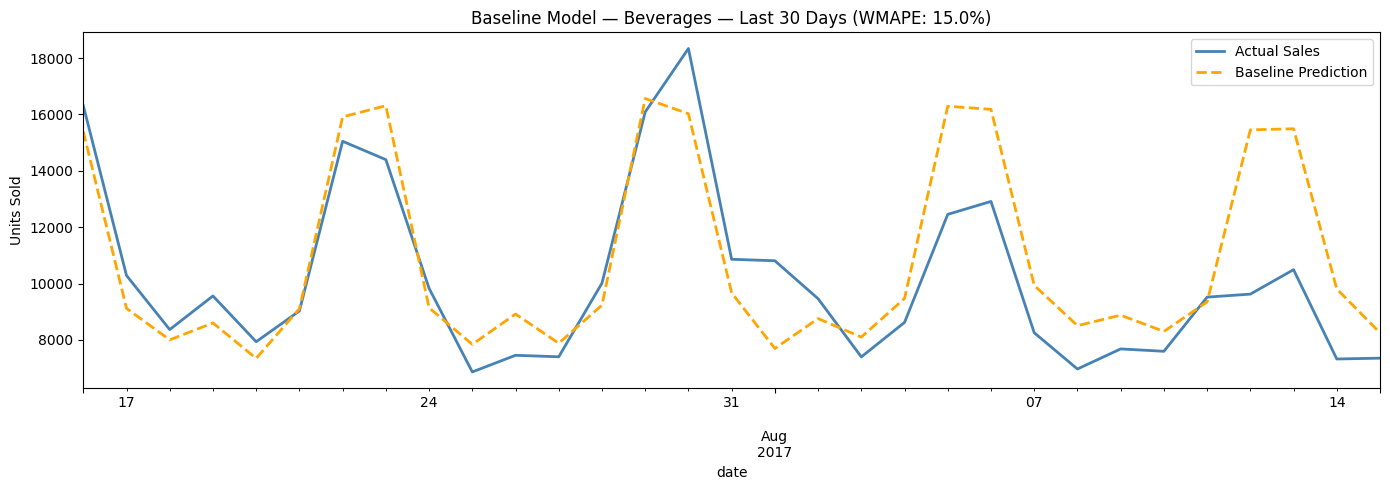

In [5]:
# Let's SEE how the baseline predictions compare to actual sales

fig, ax = plt.subplots(figsize=(14, 5))

test_data["sales"].plot(ax=ax, label="Actual Sales", color="steelblue", linewidth=2)
test_data["predicted"].plot(ax=ax, label="Baseline Prediction", 
                             color="orange", linewidth=2, linestyle="--")

ax.set_title(f"Baseline Model — Beverages — Last 30 Days (WMAPE: {wmape:.1%})")
ax.set_ylabel("Units Sold")
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# Let's see how the baseline does across different categories
# This tells us which categories are easy vs hard to predict

categories_to_test = [
    "BEVERAGES", "BREAD/BAKERY", "DAIRY", "GROCERY I", 
    "MEATS", "PRODUCE", "CLEANING", "PERSONAL CARE"
]

print("Baseline WMAPE by category (lower = better):")
print("=" * 45)

results = []
for cat in categories_to_test:
    cat_baseline = baseline_predict(store44, cat)
    cat_eval = cat_baseline.iloc[28:]
    cat_test = cat_eval[cat_eval.index >= cat_eval.index.max() - pd.Timedelta(days=30)]
    
    if cat_test["sales"].sum() > 0:
        w = compute_wmape(cat_test["sales"].values, cat_test["predicted"].values)
        results.append({"category": cat, "wmape": w})
        print(f"  {cat:<20s} WMAPE: {w:.4f} ({w*100:.1f}%)")
    else:
        print(f"  {cat:<20s} No sales in test period")

results_df = pd.DataFrame(results)
print(f"\n  {'AVERAGE':<20s} WMAPE: {results_df['wmape'].mean():.4f} ({results_df['wmape'].mean()*100:.1f}%)")
print(f"\nThese are the numbers to beat with XGBoost!")


Baseline WMAPE by category (lower = better):
  BEVERAGES            WMAPE: 0.1502 (15.0%)
  BREAD/BAKERY         WMAPE: 0.0991 (9.9%)
  DAIRY                WMAPE: 0.0893 (8.9%)
  GROCERY I            WMAPE: 0.1075 (10.7%)
  MEATS                WMAPE: 0.1044 (10.4%)
  PRODUCE              WMAPE: 0.0711 (7.1%)
  CLEANING             WMAPE: 0.1639 (16.4%)
  PERSONAL CARE        WMAPE: 0.1954 (19.5%)

  AVERAGE              WMAPE: 0.1226 (12.3%)

These are the numbers to beat with XGBoost!
